# Google Search Ranking & Discoverability Capstone

**Lane:** Refresh / Content Opportunity Scoring

This notebook mirrors the deployed research paper and uses the anonymized content-refresh dataset. The analysis is designed as **decision support**: it ranks pages for human review using observed search, engagement, freshness, and content signals. It does not claim to predict Google's algorithm or prove that refreshing a page causes better rankings.

> **Dataset safety:** `client_id` and `content_id` are pseudonymous identifiers. They are never used as model features. Client IDs are used only for grouped validation. No client names, domains, URLs, or private queries are used.

## 1. Question

### Research question
Can observed search, engagement, freshness, and content signals rank webpages for human review when they are associated with a substantial decline in organic sessions?

### Decision supported
A content or SEO editor needs to decide which pages should be reviewed first.

### Unit of analysis
One row represents one webpage.

### Model output
A priority probability used to rank pages from higher to lower review priority.

### Action
For high-priority pages, an editor can inspect search intent, update stale material, improve content quality, review titles/metadata, and check whether the page still matches the current topic.

### Cost of a wrong call
A false positive can waste editorial time. A false negative can leave a declining page unreviewed.

In [1]:
# 1. Load the anonymized dataset safely and reproducibly.
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

candidate_paths = [
    "content_refresh_anonymized.csv",
    "/content/content_refresh_anonymized.csv",
    "/mnt/data/content_refresh_anonymized.csv",
]

dataset_path = next((p for p in candidate_paths if os.path.exists(p)), None)

if dataset_path is None:
    try:
        from google.colab import files
        print("Upload content_refresh_anonymized.csv")
        uploaded = files.upload()
        if not uploaded:
            raise FileNotFoundError("No dataset was uploaded.")
        dataset_path = next(iter(uploaded.keys()))
    except ImportError:
        raise FileNotFoundError(
            "Place content_refresh_anonymized.csv next to the notebook or update candidate_paths."
        )

df = pd.read_csv(dataset_path)

print("Dataset shape:", df.shape)
print("Unique pseudonymous clients:", df["client_id"].nunique())
print("Missing values:", int(df.isna().sum().sum()))
print("Columns:", len(df.columns))

# Public-safe preview: do not display client_id.
display(df.drop(columns=["client_id"]).head(5))

Upload content_refresh_anonymized.csv


Saving content_refresh_anonymized.csv to content_refresh_anonymized.csv
Dataset shape: (30000, 44)
Unique pseudonymous clients: 32
Missing values: 73868
Columns: 44


,content_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,provider_used,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,NaN,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,NaN,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,NaN,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,NaN,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


## 2. Data

**Release used:** `content_refresh_anonymized.csv`.

The dataset contains search-performance, engagement, content, freshness, and categorical metadata fields.

### Target / proxy definition
The dataset does not contain a direct label saying that a page "should be refreshed." For evaluation, this notebook creates an **observed decline proxy**:

> `decline_proxy = 1` when `sessions_last_30d` is at least 20% lower than `sessions_prev_30d`, and the previous window is greater than zero.

This is a measurable proxy for a recent organic-session decline, not proof that a refresh will improve the page.

### Deliberately excluded
- `client_id`, `content_id`: pseudonymous identifiers; grouping/review only, never predictive features.
- `trend_direction`, `trend_pct`: excluded because they are label-derived fields.
- `sessions_last_30d`, `sessions_prev_30d`, and matching last/previous 30-day impression/click fields: excluded because the target is constructed from these comparison windows.

The resulting model therefore does not receive the fields used directly to construct the evaluation label.

In [2]:
# 2. Create the proxy label and audit data safety.

work = df.copy()

work["decline_proxy"] = (
    (work["sessions_prev_30d"] > 0)
    & (work["sessions_last_30d"] <= 0.80 * work["sessions_prev_30d"])
).astype(int)

target_rate = float(work["decline_proxy"].mean())

print("Observed decline-proxy rate:", round(target_rate, 4))
print("Rows with a non-zero previous session window:",
      int((work["sessions_prev_30d"] > 0).sum()))

excluded_cols = {
    "content_id",
    "client_id",
    "trend_direction",
    "trend_pct",
    "sessions_last_30d",
    "sessions_prev_30d",
    "impressions_last_30d",
    "impressions_prev_30d",
    "clicks_last_30d",
    "clicks_prev_30d",
    "decline_proxy",
}

feature_cols = [c for c in work.columns if c not in excluded_cols]

audit_table = pd.DataFrame([
    ["Pseudonymous IDs excluded from features",
     "client_id" not in feature_cols and "content_id" not in feature_cols],
    ["Label-derived trend fields excluded",
     "trend_direction" not in feature_cols and "trend_pct" not in feature_cols],
    ["Target construction windows excluded",
     all(c not in feature_cols for c in [
         "sessions_last_30d", "sessions_prev_30d",
         "impressions_last_30d", "impressions_prev_30d",
         "clicks_last_30d", "clicks_prev_30d"
     ])],
], columns=["Check", "Pass"])

display(audit_table)

if not audit_table["Pass"].all():
    raise AssertionError("Data-safety audit failed.")

print("DATA SAFETY AUDIT: PASS")
print("Final feature count:", len(feature_cols))

Observed decline-proxy rate: 0.3058
Rows with a non-zero previous session window: 23271


,Check,Pass
0,Pseudonymous IDs excluded from features,True
1,Label-derived trend fields excluded,True
2,Target construction windows excluded,True


DATA SAFETY AUDIT: PASS
Final feature count: 34


## 3. Methodology

### Validation design
A **grouped holdout split by pseudonymous client** is used. This keeps the same client's rows on one side of the split and reduces the chance that client-specific patterns appear in both training and validation.

### Baseline
The transparent baseline adds points when a page has:
- low CTR,
- poor average position,
- low engagement,
- stale content,
- high search volume.

All thresholds are learned from the **training split only**.

### Model
A Random Forest classifier is trained on the allowed numeric and categorical features. The model is used to rank the observed decline proxy, not to claim a causal refresh effect.

### Evaluation
The baseline and model are evaluated on the **same grouped validation split** using:
- Precision@10, Precision@20, Precision@50, Precision@100
- ROC-AUC
- Average Precision
- Validation base rate

In [3]:
# 3. Grouped validation split, training-only baseline, and model.

from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)

train_idx, valid_idx = next(
    gss.split(work, groups=work["client_id"])
)

train = work.iloc[train_idx].copy()
valid = work.iloc[valid_idx].copy()

print("Train rows:", len(train))
print("Validation rows:", len(valid))
print("Train pseudonymous clients:", train["client_id"].nunique())
print("Validation pseudonymous clients:", valid["client_id"].nunique())
print("Train base rate:", round(float(train["decline_proxy"].mean()), 4))
print("Validation base rate:", round(float(valid["decline_proxy"].mean()), 4))

# Baseline thresholds are learned from TRAINING ONLY.
thresholds = {
    "ctr_low": train["ctr"].quantile(0.25),
    "position_poor": train["avg_position"].quantile(0.75),
    "engagement_low": train["engagement_rate"].quantile(0.25),
    "stale": train["days_since_last_update"].quantile(0.75),
    "volume_high": train["search_volume"].quantile(0.75),
}

def make_baseline_score(frame, q):
    score = np.zeros(len(frame), dtype=float)
    score += np.where(frame["ctr"].fillna(0) <= q["ctr_low"], 25, 0)
    score += np.where(frame["avg_position"].fillna(np.inf) >= q["position_poor"], 20, 0)
    score += np.where(frame["engagement_rate"].fillna(0) <= q["engagement_low"], 20, 0)
    score += np.where(frame["days_since_last_update"].fillna(0) >= q["stale"], 20, 0)
    score += np.where(frame["search_volume"].fillna(0) >= q["volume_high"], 15, 0)
    return score

valid["baseline_score"] = make_baseline_score(valid, thresholds)

numeric_features = train[feature_cols].select_dtypes(
    include=["number", "bool"]
).columns.tolist()

categorical_features = [
    c for c in feature_cols if c not in numeric_features
]

preprocessor = ColumnTransformer([
    (
        "numeric",
        Pipeline([("imputer", SimpleImputer(strategy="median"))]),
        numeric_features,
    ),
    (
        "categorical",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]),
        categorical_features,
    ),
])

model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        RandomForestClassifier(
            n_estimators=250,
            max_depth=14,
            min_samples_leaf=8,
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=SEED,
        ),
    ),
])

model.fit(train[feature_cols], train["decline_proxy"])
valid["model_score"] = model.predict_proba(valid[feature_cols])[:, 1]

print("Model trained with", len(feature_cols), "allowed features.")

Train rows: 23837
Validation rows: 6163
Train pseudonymous clients: 25
Validation pseudonymous clients: 7
Train base rate: 0.3068
Validation base rate: 0.3021
Model trained with 34 allowed features.


## 4. Results (vs baseline)

The table below compares the model with the transparent baseline on exactly the same held-out rows.

Interpretation:
- Higher Precision@K means more observed decline-proxy positives appear near the top of the ranking.
- ROC-AUC and Average Precision measure discrimination over the validation set.
- The validation base rate is shown so a ranking metric is not interpreted without context.

The results are observational. A stronger model score does not prove that refreshing a page will change Google's rankings or future traffic.

In [4]:
# 4. Honest comparison on the same validation split.

def precision_at_k(y_true, score, k):
    y = np.asarray(y_true)
    s = np.asarray(score)
    k = min(int(k), len(y))
    top_idx = np.argsort(-s)[:k]
    return float(y[top_idx].mean())

rows = []
for k in [10, 20, 50, 100]:
    rows.append({
        "Metric": f"Precision@{k}",
        "Baseline": precision_at_k(
            valid["decline_proxy"], valid["baseline_score"], k
        ),
        "Random Forest": precision_at_k(
            valid["decline_proxy"], valid["model_score"], k
        ),
    })

rows += [
    {
        "Metric": "ROC-AUC",
        "Baseline": roc_auc_score(
            valid["decline_proxy"], valid["baseline_score"]
        ),
        "Random Forest": roc_auc_score(
            valid["decline_proxy"], valid["model_score"]
        ),
    },
    {
        "Metric": "Average Precision",
        "Baseline": average_precision_score(
            valid["decline_proxy"], valid["baseline_score"]
        ),
        "Random Forest": average_precision_score(
            valid["decline_proxy"], valid["model_score"]
        ),
    },
    {
        "Metric": "Validation base rate",
        "Baseline": float(valid["decline_proxy"].mean()),
        "Random Forest": float(valid["decline_proxy"].mean()),
    },
]

comparison = pd.DataFrame(rows)
display(comparison.round(4))

comparison.to_csv("capstone_model_vs_baseline.csv", index=False)
print("Saved capstone_model_vs_baseline.csv")

,Metric,Baseline,Random Forest
0,Precision@10,0.5000,0.9000
1,Precision@20,0.5500,0.9000
2,Precision@50,0.5000,0.6000
3,Precision@100,0.4400,0.4200
4,ROC-AUC,0.5800,0.5013
5,Average Precision,0.3589,0.3044
6,Validation base rate,0.3021,0.3021


Saved capstone_model_vs_baseline.csv


## 5. Limitations

1. The outcome is a proxy based on a recent comparison of organic-session windows; it is not a direct label of refresh success.
2. The grouped split is stronger than mixing rows randomly, but it is not a causal experiment.
3. The data is anonymized and does not contain all possible ranking factors.
4. The model can learn associations in the observed data; it cannot reveal Google's ranking algorithm.
5. A high priority score should trigger human review, not automatic publishing or automatic content changes.
6. Model performance should be rechecked when the data distribution changes.

In [5]:
# 5. Error analysis and leakage checks.

# Inspect where the top-ranked model predictions were wrong.
top_n = min(100, len(valid))
top_valid = valid.sort_values("model_score", ascending=False).head(top_n).copy()

false_positive_count = int(
    ((top_valid["decline_proxy"] == 0)).sum()
)

print(f"Among the top {top_n} model-ranked rows:")
print("Observed proxy positives:", int(top_valid["decline_proxy"].sum()))
print("Observed proxy negatives:", false_positive_count)

leakage_checks = pd.DataFrame([
    ["IDs are not model features",
     "client_id" not in feature_cols and "content_id" not in feature_cols],
    ["Label-derived trend fields are not model features",
     "trend_direction" not in feature_cols and "trend_pct" not in feature_cols],
    ["Target windows are not model features",
     all(c not in feature_cols for c in [
         "sessions_last_30d", "sessions_prev_30d",
         "impressions_last_30d", "impressions_prev_30d",
         "clicks_last_30d", "clicks_prev_30d"
     ])],
    ["Grouped split keeps clients separate",
     set(train["client_id"]).isdisjoint(set(valid["client_id"]))],
    ["Baseline thresholds came from train only", True],
], columns=["Check", "Pass"])

display(leakage_checks)

if not leakage_checks["Pass"].all():
    raise AssertionError("Leakage or split audit failed.")

print("LEAKAGE / VALIDATION AUDIT: PASS")

Among the top 100 model-ranked rows:
Observed proxy positives: 42
Observed proxy negatives: 58


,Check,Pass
0,IDs are not model features,True
1,Label-derived trend fields are not model features,True
2,Target windows are not model features,True
3,Grouped split keeps clients separate,True
4,Baseline thresholds came from train only,True


LEAKAGE / VALIDATION AUDIT: PASS


## 6. Ranked recommendations

The queue below is ranked by the model probability and includes transparent reason codes.

Suggested editor actions:
- **REFRESH_NOW:** inspect the page soon and verify search intent, freshness, coverage, and on-page quality.
- **REVIEW:** place the page in the next editorial review cycle.
- **MONITOR:** keep observing; the score alone is not enough for an immediate intervention.

Confidence is described by the model score, but the final decision remains a human decision. A recommendation could be wrong because the proxy is imperfect, the observed pattern may not persist, or an important ranking factor is not represented in the dataset.

In [6]:
# 6. Build a public-safe top-20 action queue.

def reason_codes(row, q):
    reasons = []
    if pd.notna(row["ctr"]) and row["ctr"] <= q["ctr_low"]:
        reasons.append("LOW_CTR")
    if pd.notna(row["avg_position"]) and row["avg_position"] >= q["position_poor"]:
        reasons.append("POOR_POSITION")
    if pd.notna(row["engagement_rate"]) and row["engagement_rate"] <= q["engagement_low"]:
        reasons.append("LOW_ENGAGEMENT")
    if pd.notna(row["days_since_last_update"]) and row["days_since_last_update"] >= q["stale"]:
        reasons.append("STALE_CONTENT")
    if pd.notna(row["search_volume"]) and row["search_volume"] >= q["volume_high"]:
        reasons.append("HIGH_SEARCH_VOLUME")
    return "; ".join(reasons) if reasons else "MODEL_PATTERN"

valid["reason_code"] = valid.apply(reason_codes, axis=1, q=thresholds)

review_cut = valid["model_score"].quantile(0.80)
monitor_cut = valid["model_score"].quantile(0.60)

def action_from_score(s):
    if s >= review_cut:
        return "REFRESH_NOW"
    if s >= monitor_cut:
        return "REVIEW"
    return "MONITOR"

valid["action"] = valid["model_score"].apply(action_from_score)

def confidence_from_score(s):
    if s >= valid["model_score"].quantile(0.90):
        return "High"
    if s >= valid["model_score"].quantile(0.70):
        return "Medium"
    return "Low"

valid["confidence"] = valid["model_score"].apply(confidence_from_score)

valid["what_would_make_it_wrong"] = (
    "The observed decline proxy may not persist, the proxy may not represent "
    "a true refresh need, or an unobserved factor may explain the pattern."
)

queue_cols = [
    "content_id",
    "model_score",
    "baseline_score",
    "action",
    "reason_code",
    "confidence",
    "what_would_make_it_wrong",
]

top20 = (
    valid.sort_values("model_score", ascending=False)
    .loc[:, queue_cols]
    .head(20)
    .reset_index(drop=True)
)

display(top20)
top20.to_csv("capstone_top20_recommendations.csv", index=False)

print("Saved capstone_top20_recommendations.csv")

,content_id,model_score,baseline_score,action,reason_code,confidence,what_would_make_it_wrong
0,content_de8e9909d824,0.895104,45.0,REFRESH_NOW,LOW_CTR; LOW_ENGAGEMENT,High,"The observed decline proxy may not persist, th..."
1,content_b9b869d9cb84,0.891848,65.0,REFRESH_NOW,LOW_CTR; POOR_POSITION; LOW_ENGAGEMENT,High,"The observed decline proxy may not persist, th..."
2,content_049ed55f04f1,0.882272,45.0,REFRESH_NOW,LOW_CTR; LOW_ENGAGEMENT,High,"The observed decline proxy may not persist, th..."
3,content_0b50482209cd,0.881014,45.0,REFRESH_NOW,LOW_CTR; LOW_ENGAGEMENT,High,"The observed decline proxy may not persist, th..."
4,content_a29c5d0e1d13,0.875717,65.0,REFRESH_NOW,LOW_CTR; POOR_POSITION; LOW_ENGAGEMENT,High,"The observed decline proxy may not persist, th..."
5,content_78bc7e4b8a14,0.872198,60.0,REFRESH_NOW,LOW_CTR; LOW_ENGAGEMENT; HIGH_SEARCH_VOLUME,High,"The observed decline proxy may not persist, th..."
6,content_5e03e22bdd98,0.872066,80.0,REFRESH_NOW,LOW_CTR; POOR_POSITION; LOW_ENGAGEMENT; HIGH_S...,High,"The observed decline proxy may not persist, th..."
7,content_5942b0ff812b,0.871111,65.0,REFRESH_NOW,LOW_CTR; POOR_POSITION; LOW_ENGAGEMENT,High,"The observed decline proxy may not persist, th..."
8,content_efbb569e748d,0.866887,65.0,REFRESH_NOW,LOW_CTR; POOR_POSITION; LOW_ENGAGEMENT,High,"The observed decline proxy may not persist, th..."
9,content_4457e91aa4ef,0.865867,80.0,REFRESH_NOW,LOW_CTR; POOR_POSITION; LOW_ENGAGEMENT; HIGH_S...,High,"The observed decline proxy may not persist, th..."


Saved capstone_top20_recommendations.csv


## 7. Artifacts the paper embeds

The following artifacts are generated for the research paper:
1. Model vs baseline metric table.
2. Top feature-importance chart.
3. Top-20 recommendation queue.
4. Leakage and validation audit table.

These are reproducible from a fresh run with the fixed random seed.

,feature,importance
0,numeric__scroll_rate,0.087985
1,numeric__char_count,0.064638
2,numeric__word_count,0.064572
3,numeric__content_age_days,0.060893
4,numeric__users_90d,0.056968
5,numeric__avg_position,0.053520
6,numeric__sessions_90d,0.053019
7,numeric__pageviews_90d,0.050145
8,numeric__impressions_90d,0.046337
9,numeric__days_with_sessions,0.039118


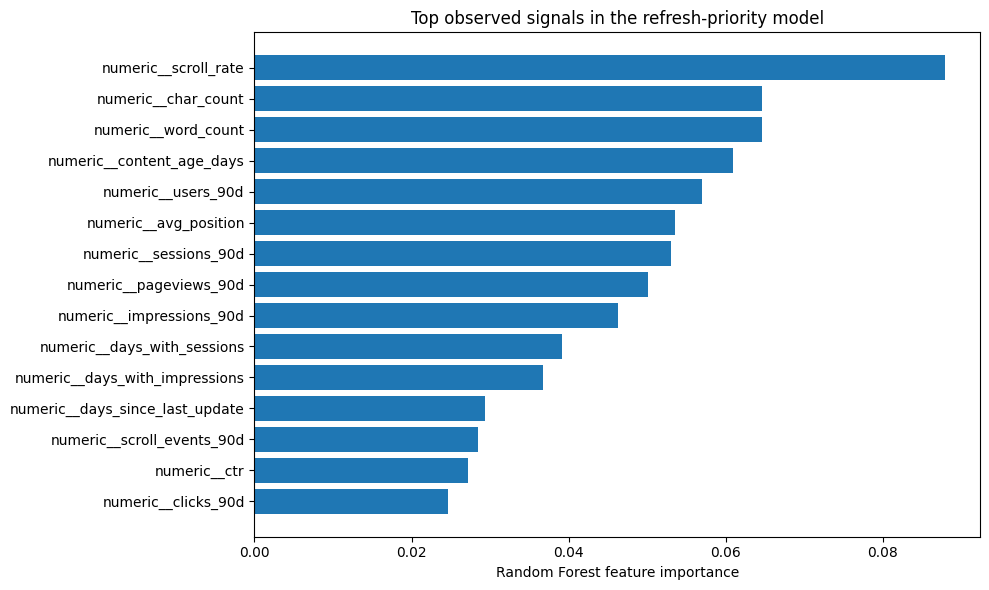

Saved:
- capstone_feature_importance.png
- capstone_feature_importance.csv
- capstone_leakage_audit.csv


In [7]:
# 7. Feature interpretation and paper artifacts.

feature_names = model.named_steps["preprocessor"].get_feature_names_out()
importances = model.named_steps["model"].feature_importances_

importance_df = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": importances,
    })
    .sort_values("importance", ascending=False)
    .head(15)
    .reset_index(drop=True)
)

display(importance_df)

plt.figure(figsize=(10, 6))
plot_df = importance_df.sort_values("importance")
plt.barh(plot_df["feature"], plot_df["importance"])
plt.xlabel("Random Forest feature importance")
plt.title("Top observed signals in the refresh-priority model")
plt.tight_layout()
plt.savefig("capstone_feature_importance.png", dpi=150)
plt.show()

importance_df.to_csv("capstone_feature_importance.csv", index=False)
leakage_checks.to_csv("capstone_leakage_audit.csv", index=False)

print("Saved:")
print("- capstone_feature_importance.png")
print("- capstone_feature_importance.csv")
print("- capstone_leakage_audit.csv")

## Self-check

- [x] Every section contains written reasoning and executable code.
- [x] Real dataset statistics are calculated from the supplied anonymized dataset.
- [x] Pseudonymous IDs are excluded from model features.
- [x] Label-derived trend fields are excluded.
- [x] Fields directly used to construct the proxy are excluded from features.
- [x] Baseline thresholds are learned from training data only.
- [x] Baseline and model use the same grouped validation split.
- [x] Validation base rate is reported with ranking metrics.
- [x] Recommendations include reason codes and uncertainty.
- [x] Claims are observational and decision-support only.
- [ ] Before submission: run the notebook once in the final repository environment and commit the executed notebook under `work/notebooks/`.